# vOTU Blocks: Supplemented Microbial Reference

Combine original and source-isolate bacterial regions and select one block per vOTU.

## Notebook Setup

Shared clustering provides candidates; direct 95/85/85 support and mapping breadth determine eligibility and rank.

In [1]:
# Load core libraries and define notebook settings
from pathlib import Path
import os
import shutil
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting preferences
sns.set_style(
    "ticks",
    {
        "axes.grid": True,
        "grid.color": "#BFBFBF",
        "grid.linestyle": "-",
        "grid.linewidth": 0.35,
        "axes.facecolor": "white",
        "figure.facecolor": "white",
    },
)
sns.set_palette("colorblind")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
    "savefig.bbox": "tight",
    "axes.linewidth": 0.7,
    "axes.edgecolor": "#222222",
    "xtick.major.width": 0.7,
    "ytick.major.width": 0.7,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
    "xtick.major.size": 4.5,
    "ytick.major.size": 4.5,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "grid.linewidth": 0.35,
    "grid.alpha": 0.8,
    "patch.linewidth": 0.7,
    "lines.linewidth": 1.0,
    "lines.markersize": 4,
    "font.family": "sans-serif",
    "font.sans-serif": ["Liberation Sans"],
    "text.usetex": False,
    "font.size": 5,
    "axes.titlepad": 5,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "legend.frameon": True,
    "legend.fancybox": False,
    "legend.framealpha": 1.0,
    "legend.edgecolor": "#444444",
    "legend.facecolor": "white",
    "legend.fontsize": 5,
    "legend.title_fontsize": 6,
    "savefig.dpi": 300,
    "figure.dpi": 150,
    "svg.fonttype": "none",
})

VIRAL_FRACTION_DIR = Path('/home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION')
VIRAL_WORLD_DIR = VIRAL_FRACTION_DIR.parent
BACTERIAL_FRACTION_DIR = VIRAL_WORLD_DIR / 'BACTERIAL_FRACTION'
MICROBIAL_GENOMES_DIR = BACTERIAL_FRACTION_DIR / 'MICROBIAL_GENOMES_PHYLLOVIR'

SAMPLES_36 = [
    'vFL', 'vOL', 'vF23',
    'vN1', 'vN2', 'vN3',
    'vZ1', 'vZ2', 'vZ3',
    'vF1A', 'vF2A', 'vF3A',
    'vF1B', 'vF2B', 'vF3B',
    'vF1C', 'vF2C', 'vF3C',
    'vO1A', 'vO2A', 'vO3A',
    'vO1B', 'vO2B', 'vO3B',
    'vO1C', 'vO2C', 'vO3C',
    'vS1B', 'vS2B', 'vS3B',
    'vS1C', 'vS2C', 'vS3C',
    'vNWd', 'vSWd', 'vSEd',
]

VOTU_METADATA_PATH = VIRAL_FRACTION_DIR / 'vOTU_metadata.csv'
VOTU_FASTA_PATH = (
    VIRAL_FRACTION_DIR / '05_vOTUs' / 'filtered_95-85_positive_viral_contigs.tot.fasta'
)

# Unified reference and its derived metadata/viral-region table.
REFERENCE_STEM = 'strains_in_microbial_fraction_2018_supplemented_with_phage_source_isolates'
STRAIN_REFERENCE_FASTA_PATH = VIRAL_FRACTION_DIR / f'{REFERENCE_STEM}.fasta'
STRAIN_CONTIG_METADATA_PATH = VIRAL_FRACTION_DIR / f'{REFERENCE_STEM}.seqtk_comp.with_source.tsv'
GENOMAD_VIRAL_REGIONS_PATH = VIRAL_FRACTION_DIR / f'{REFERENCE_STEM}_geNomad_viral_regions.tsv'
SOURCE_ISOLATE_MANIFEST_PATH = VIRAL_FRACTION_DIR / f'{REFERENCE_STEM}.manifest.tsv'

# The original hits are retained. Only the small source-isolate BLAST is regenerated,
# then both hit sets are combined before interval construction and clustering.
ORIGINAL_VOTU_VS_STRAIN_BLAST_PATH = (
    MICROBIAL_GENOMES_DIR / 'vOTUs_vs_strains_in_microbial_fraction_2018_blastout.tsv'
)
SOURCE_ISOLATE_FASTA_PATH = (
    VIRAL_FRACTION_DIR / 'Erwinia_Pseudomonas_57_source_isolate_genomes.fasta'
)
SOURCE_VOTU_VS_STRAIN_BLAST_PATH = (
    VIRAL_FRACTION_DIR / 'vOTUs_vs_Erwinia_Pseudomonas_57_source_isolate_genomes_blastout.tsv'
)
VOTU_VS_STRAIN_BLAST_PATH = (
    VIRAL_FRACTION_DIR / f'vOTUs_vs_{REFERENCE_STEM}_combined_blastout.tsv'
)

REFERENCES_DIR = VIRAL_FRACTION_DIR / '06_MAPPING' / 'REFERENCES'
MAPPING_REFERENCE_PREFIX = REFERENCE_STEM
VOTU_CLUSTERING_SCRIPT = Path('/home/lmf/scripts/vOTU_clustering.sh')

MIN_BLAST_QUERY_COVERAGE = 85.0
MIN_DIRECT_PAIRWISE_PID = 95.0
MIN_DIRECT_PAIRWISE_QCOV = 85.0
MIN_DIRECT_PAIRWISE_TCOV = 85.0
MERGE_DISTANCE_BP = 10_000
MIN_BLOCK_LENGTH_BP = 5_000
MIN_HOST_CONTIG_LENGTH_BP = 100_000
MAX_HOST_CONTIG_GENOMAD_VIRAL_FRACTION = 0.80

# These are True for the first supplemented run. Set them False after the source BLAST
# and combined clustering outputs have been generated successfully.
RUN_SOURCE_VOTU_BLAST = False
RUN_VOTU_CLUSTERING = False
BLAST_THREADS = 16
MAKE_PLOTS = True

BLAST_COLUMNS = [
    'qseqid', 'sseqid', 'salltitles', 'qstart', 'qend', 'sstart', 'send',
    'qlen', 'slen', 'qcovs', 'evalue', 'length', 'pident',
]
STRAIN_CONTIG_COLUMNS = [
    'target_seq', 'sequence_length', 'A', 'C', 'G', 'T', '#2', '#3', '#4',
    '#CpG', '#tv', '#ts', '#CpG-ts', 'genome',
]

WORK_DIR = VIRAL_FRACTION_DIR / '09_vOTU_block_test_set_supplemented_work'
WORK_DIR.mkdir(parents=True, exist_ok=True)
EXTRACTED_REGION_FASTA_PATH = WORK_DIR / f'{REFERENCE_STEM}_blasted_regions.fasta'
COMBINED_FASTA_PATH = WORK_DIR / f'{REFERENCE_STEM}_blasted_regions_and_vOTUs.fasta'
CLUSTER_PATH = WORK_DIR / f'{COMBINED_FASTA_PATH.stem}_vOTUs_clusters.txt'
ANI_PATH = Path(f'{COMBINED_FASTA_PATH}_aniout')

OUTPUT_DIR = (
    VIRAL_FRACTION_DIR / 'FIGURES_AND_TABLES' / 'SUPPLEMENTARY'
    / '09_vOTU_block_test_set'
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
outputs = {
    'host_contig_eligibility': OUTPUT_DIR / '09_host_contig_eligibility.csv',
    'host_contig_filter_summary': OUTPUT_DIR / '09_host_contig_filter_summary.csv',
    'blast_blocks': OUTPUT_DIR / '09_blast_blocks.csv',
    'fasta_check': OUTPUT_DIR / '09_blasted_region_fasta_check.csv',
    'clustered_candidates': OUTPUT_DIR / '09_clustered_vOTU_block_candidates.csv',
    'selected_blocks': OUTPUT_DIR / '09_vOTU_blocks_clustered_coverage_ranked.csv',
    'summary': OUTPUT_DIR / '09_vOTU_block_selection_summary.csv',
    'figure': OUTPUT_DIR / '09_vOTU_block_selection.svg',
}

os.environ.update({
    'RUN_SOURCE_VOTU_BLAST': str(RUN_SOURCE_VOTU_BLAST).lower(),
    'RUN_VOTU_CLUSTERING': str(RUN_VOTU_CLUSTERING).lower(),
    'BLAST_THREADS': str(BLAST_THREADS),
    'VOTU_FASTA_PATH': str(VOTU_FASTA_PATH),
    'SOURCE_ISOLATE_FASTA_PATH': str(SOURCE_ISOLATE_FASTA_PATH),
    'SOURCE_VOTU_VS_STRAIN_BLAST_PATH': str(SOURCE_VOTU_VS_STRAIN_BLAST_PATH),
    'COMBINED_FASTA_PATH': str(COMBINED_FASTA_PATH),
    'VOTU_CLUSTERING_SCRIPT': str(VOTU_CLUSTERING_SCRIPT),
})


## Source-Isolate vOTU BLAST

Optional BLAST against the 57 source-isolate genomes.

In [2]:
%%bash
set -euo pipefail

if [[ "${RUN_SOURCE_VOTU_BLAST}" != "true" ]]; then
    echo "Skipped: set RUN_SOURCE_VOTU_BLAST = True to regenerate source-isolate hits."
    exit 0
fi

makeblastdb \
    -in "${SOURCE_ISOLATE_FASTA_PATH}" \
    -dbtype nucl \
    -out "${SOURCE_ISOLATE_FASTA_PATH}"

blastn \
    -query "${VOTU_FASTA_PATH}" \
    -db "${SOURCE_ISOLATE_FASTA_PATH}" \
    -out "${SOURCE_VOTU_VS_STRAIN_BLAST_PATH}" \
    -outfmt "6 qseqid sseqid salltitles qstart qend sstart send qlen slen qcovs evalue length pident" \
    -max_target_seqs 10000 \
    -num_threads "${BLAST_THREADS}"

echo "Saved source-isolate BLAST hits: ${SOURCE_VOTU_VS_STRAIN_BLAST_PATH}"


Skipped: set RUN_SOURCE_VOTU_BLAST = True to regenerate source-isolate hits.


## vOTU-to-Host Block Candidates

### Eligible Host Contigs

Require contigs ≥100 kb with <80% merged geNomad viral coverage.

In [3]:
# Identify eligible bacterial host contigs
# Build the eligible bacterial-host contig table before parsing BLAST intervals.
host_filter_paths = [STRAIN_CONTIG_METADATA_PATH, GENOMAD_VIRAL_REGIONS_PATH]
missing_host_filter_paths = [str(path) for path in host_filter_paths if not path.exists()]
if missing_host_filter_paths:
    raise FileNotFoundError(f'Missing host-contig filter inputs: {missing_host_filter_paths}')

strain_contigs = pd.read_csv(
    STRAIN_CONTIG_METADATA_PATH,
    sep='\t',
    header=None,
    names=STRAIN_CONTIG_COLUMNS,
    usecols=[0, 1, 13],
)
strain_contigs['target_seq'] = (
    strain_contigs['target_seq'].astype(str).str.strip().str.replace('-', '_', regex=False)
)
strain_contigs['genome'] = strain_contigs['genome'].astype(str).str.strip()
strain_contigs['sequence_length'] = pd.to_numeric(
    strain_contigs['sequence_length'], errors='raise'
).astype(int)

source_manifest = pd.read_csv(SOURCE_ISOLATE_MANIFEST_PATH, sep='\t')
added_source_genomes = set(
    source_manifest.loc[source_manifest['integration_status'].eq('added'), 'source_isolate']
    .astype(str).str.strip()
)
strain_contigs['reference_origin'] = np.where(
    strain_contigs['genome'].isin(added_source_genomes),
    'source_isolate_added',
    'original_2018',
)
if strain_contigs['target_seq'].duplicated().any():
    duplicate_contigs = strain_contigs.loc[
        strain_contigs['target_seq'].duplicated(), 'target_seq'
    ].head().tolist()
    raise ValueError(f'Reference-contig identifiers are not unique: {duplicate_contigs}')

genomad_regions = pd.read_csv(
    GENOMAD_VIRAL_REGIONS_PATH,
    sep='\t',
    usecols=['target_seq', 'start_1based', 'end_1based_inclusive'],
)
genomad_regions['target_seq'] = (
    genomad_regions['target_seq'].astype(str).str.strip().str.replace('-', '_', regex=False)
)
for column in ['start_1based', 'end_1based_inclusive']:
    genomad_regions[column] = pd.to_numeric(genomad_regions[column], errors='raise').astype(int)

genomad_regions = genomad_regions.merge(
    strain_contigs[['target_seq', 'sequence_length']],
    on='target_seq',
    how='left',
    validate='many_to_one',
)
unmatched_genomad_regions = int(genomad_regions['sequence_length'].isna().sum())
if unmatched_genomad_regions:
    raise ValueError(
        f'{unmatched_genomad_regions} geNomad regions could not be matched to a reference contig.'
    )

# Clip coordinates to each contig, then merge overlapping regions before calculating
# viral coverage so overlap is never counted twice.
genomad_regions['start'] = genomad_regions['start_1based'].clip(lower=1)
genomad_regions['end'] = np.minimum(
    genomad_regions['end_1based_inclusive'],
    genomad_regions['sequence_length'],
).astype(int)
genomad_regions = genomad_regions.loc[
    genomad_regions['end'].ge(genomad_regions['start'])
].copy()

merged_region_rows = []
for target_seq, group in genomad_regions.groupby('target_seq', sort=False):
    current_start = None
    current_end = None
    for row in group.sort_values(['start', 'end']).itertuples(index=False):
        start = int(row.start)
        end = int(row.end)
        if current_start is None:
            current_start, current_end = start, end
        elif start <= current_end + 1:
            current_end = max(current_end, end)
        else:
            merged_region_rows.append({
                'target_seq': target_seq,
                'start': current_start,
                'end': current_end,
            })
            current_start, current_end = start, end
    if current_start is not None:
        merged_region_rows.append({
            'target_seq': target_seq,
            'start': current_start,
            'end': current_end,
        })

merged_genomad_regions = pd.DataFrame(
    merged_region_rows,
    columns=['target_seq', 'start', 'end'],
)
if merged_genomad_regions.empty:
    viral_coverage_by_contig = pd.DataFrame(
        columns=['target_seq', 'geNomad_viral_bp', 'n_merged_geNomad_viral_regions']
    )
else:
    merged_genomad_regions['geNomad_viral_bp'] = (
        merged_genomad_regions['end'] - merged_genomad_regions['start'] + 1
    )
    viral_coverage_by_contig = (
        merged_genomad_regions
        .groupby('target_seq', as_index=False)
        .agg(
            geNomad_viral_bp=('geNomad_viral_bp', 'sum'),
            n_merged_geNomad_viral_regions=('target_seq', 'size'),
        )
    )

host_contig_eligibility = strain_contigs.merge(
    viral_coverage_by_contig,
    on='target_seq',
    how='left',
    validate='one_to_one',
)
host_contig_eligibility['geNomad_viral_bp'] = (
    host_contig_eligibility['geNomad_viral_bp'].fillna(0).astype(int)
)
host_contig_eligibility['n_merged_geNomad_viral_regions'] = (
    host_contig_eligibility['n_merged_geNomad_viral_regions'].fillna(0).astype(int)
)
host_contig_eligibility['geNomad_viral_fraction'] = (
    host_contig_eligibility['geNomad_viral_bp']
    / host_contig_eligibility['sequence_length']
).clip(upper=1)
host_contig_eligibility['passes_length_filter'] = (
    host_contig_eligibility['sequence_length'].ge(MIN_HOST_CONTIG_LENGTH_BP)
)
host_contig_eligibility['passes_viral_content_filter'] = (
    host_contig_eligibility['geNomad_viral_fraction']
    .lt(MAX_HOST_CONTIG_GENOMAD_VIRAL_FRACTION)
)
host_contig_eligibility['eligible_for_votu_blocks'] = (
    host_contig_eligibility['passes_length_filter']
    & host_contig_eligibility['passes_viral_content_filter']
)
host_contig_eligibility['filter_reason'] = np.select(
    [
        ~host_contig_eligibility['passes_length_filter']
        & ~host_contig_eligibility['passes_viral_content_filter'],
        ~host_contig_eligibility['passes_length_filter'],
        ~host_contig_eligibility['passes_viral_content_filter'],
    ],
    [
        'below_length_and_geNomad_viral_dominated',
        'below_length',
        'geNomad_viral_dominated',
    ],
    default='eligible',
)

eligible_strain_contigs = host_contig_eligibility.loc[
    host_contig_eligibility['eligible_for_votu_blocks']
].copy()
eligible_contig_ids = set(eligible_strain_contigs['target_seq'])

host_contig_filter_summary = pd.DataFrame([
    {
        'step': 'All strain-reference contigs',
        'n_contigs': len(host_contig_eligibility),
        'n_genomes': host_contig_eligibility['genome'].nunique(),
        'total_bp': host_contig_eligibility['sequence_length'].sum(),
    },
    {
        'step': f'Contigs >= {MIN_HOST_CONTIG_LENGTH_BP:,} bp',
        'n_contigs': int(host_contig_eligibility['passes_length_filter'].sum()),
        'n_genomes': host_contig_eligibility.loc[
            host_contig_eligibility['passes_length_filter'], 'genome'
        ].nunique(),
        'total_bp': host_contig_eligibility.loc[
            host_contig_eligibility['passes_length_filter'], 'sequence_length'
        ].sum(),
    },
    {
        'step': (
            f'Eligible: >= {MIN_HOST_CONTIG_LENGTH_BP:,} bp and '
            f'< {MAX_HOST_CONTIG_GENOMAD_VIRAL_FRACTION:.0%} geNomad viral coverage'
        ),
        'n_contigs': len(eligible_strain_contigs),
        'n_genomes': eligible_strain_contigs['genome'].nunique(),
        'total_bp': eligible_strain_contigs['sequence_length'].sum(),
    },
    {
        'step': (
            f'>= {MIN_HOST_CONTIG_LENGTH_BP:,} bp excluded at '
            f'>= {MAX_HOST_CONTIG_GENOMAD_VIRAL_FRACTION:.0%} geNomad viral coverage'
        ),
        'n_contigs': int((
            host_contig_eligibility['passes_length_filter']
            & ~host_contig_eligibility['passes_viral_content_filter']
        ).sum()),
        'n_genomes': host_contig_eligibility.loc[
            host_contig_eligibility['passes_length_filter']
            & ~host_contig_eligibility['passes_viral_content_filter'],
            'genome',
        ].nunique(),
        'total_bp': host_contig_eligibility.loc[
            host_contig_eligibility['passes_length_filter']
            & ~host_contig_eligibility['passes_viral_content_filter'],
            'sequence_length',
        ].sum(),
    },
])
host_contig_eligibility.to_csv(outputs['host_contig_eligibility'], index=False)
host_contig_filter_summary.to_csv(outputs['host_contig_filter_summary'], index=False)
host_contig_filter_summary


,step,n_contigs,n_genomes,total_bp
0,All strain-reference contigs,140850,2071,11151369299
1,"Contigs >= 100,000 bp",19939,2044,9495017404
2,"Eligible: >= 100,000 bp and < 80% geNomad vira...",19933,2044,9494269267
3,">= 100,000 bp excluded at >= 80% geNomad viral...",6,6,748137


In [4]:
# Combine original and source-isolate vOTU BLAST hits
required_paths = [
    VOTU_METADATA_PATH,
    VOTU_FASTA_PATH,
    STRAIN_REFERENCE_FASTA_PATH,
    ORIGINAL_VOTU_VS_STRAIN_BLAST_PATH,
    SOURCE_VOTU_VS_STRAIN_BLAST_PATH,
    STRAIN_CONTIG_METADATA_PATH,
    GENOMAD_VIRAL_REGIONS_PATH,
    SOURCE_ISOLATE_MANIFEST_PATH,
]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError(f'Missing required input files: {missing_paths}')

votu_metadata = pd.read_csv(VOTU_METADATA_PATH, low_memory=False)
votu_metadata['vOTU'] = votu_metadata['vOTU'].astype(str).str.strip()
metadata_columns = [
    column for column in [
        'vOTU', 'vOTU_number', 'vOTU_name_final', 'prophage',
        'widespread_name', 'isolate_host_genus', 'checkV_contig_length',
        'INTERESTING', 'COMPARISON',
    ] if column in votu_metadata.columns
]
votu_metadata = votu_metadata[metadata_columns].drop_duplicates('vOTU')

def read_blast_table(path: Path) -> pd.DataFrame:
    table = pd.read_csv(
        path,
        sep='\t',
        header=None,
        names=BLAST_COLUMNS,
        low_memory=False,
    )
    table['qseqid'] = table['qseqid'].astype(str).str.strip()
    table['sseqid'] = (
        table['sseqid'].astype(str).str.strip().str.replace('-', '_', regex=False)
    )
    return table

supplemented_contig_ids = set(strain_contigs['target_seq'])
original_blast_hits = read_blast_table(ORIGINAL_VOTU_VS_STRAIN_BLAST_PATH)
source_blast_hits_all = read_blast_table(SOURCE_VOTU_VS_STRAIN_BLAST_PATH)
source_blast_hits = source_blast_hits_all.loc[
    source_blast_hits_all['sseqid'].isin(supplemented_contig_ids)
].copy()
source_hits_excluded_as_duplicate_representations = (
    len(source_blast_hits_all) - len(source_blast_hits)
)

unmatched_original_contigs = sorted(
    set(original_blast_hits['sseqid']) - supplemented_contig_ids
)
if unmatched_original_contigs:
    raise ValueError(
        'Original BLAST hits contain contigs absent from the supplemented reference: '
        f'{unmatched_original_contigs[:5]}'
    )

combined_blast_hits = (
    pd.concat([original_blast_hits, source_blast_hits], ignore_index=True)
    .drop_duplicates(BLAST_COLUMNS)
    .sort_values(['qseqid', 'sseqid', 'sstart', 'send'], kind='mergesort')
    .reset_index(drop=True)
)
combined_blast_hits.to_csv(
    VOTU_VS_STRAIN_BLAST_PATH,
    sep='\t',
    header=False,
    index=False,
)
print(
    f'Combined BLAST hits: {len(original_blast_hits):,} original + '
    f'{len(source_blast_hits):,} source-isolate; '
    f'{source_hits_excluded_as_duplicate_representations:,} source hits excluded '
    'because that isolate representation was not appended.'
)
print(f'Saved combined BLAST table: {VOTU_VS_STRAIN_BLAST_PATH}')

raw_blast_hits = combined_blast_hits[
    ['qseqid', 'sseqid', 'sstart', 'send', 'qcovs', 'pident']
].copy()
for column in ['sstart', 'send', 'qcovs', 'pident']:
    raw_blast_hits[column] = pd.to_numeric(raw_blast_hits[column], errors='raise')

# Filter raw hits before they become intervals, FASTA records, or clustering members.
blast_hits = raw_blast_hits.merge(
    host_contig_eligibility[
        ['target_seq', 'eligible_for_votu_blocks']
    ].rename(columns={'target_seq': 'sseqid'}),
    on='sseqid',
    how='left',
    validate='many_to_one',
)
unmatched_blast_contigs = int(blast_hits['eligible_for_votu_blocks'].isna().sum())
if unmatched_blast_contigs:
    raise ValueError(
        f'{unmatched_blast_contigs} BLAST hits could not be matched to host-contig metadata.'
    )
n_blast_hits_excluded_by_host_filter = int(
    (~blast_hits['eligible_for_votu_blocks']).sum()
)
blast_hits = blast_hits.loc[
    blast_hits['eligible_for_votu_blocks']
].drop(columns='eligible_for_votu_blocks').copy()
if not set(blast_hits['sseqid']).issubset(eligible_contig_ids):
    raise ValueError('An ineligible bacterial contig reached BLAST interval parsing.')

candidate_hits = blast_hits.loc[
    blast_hits['qcovs'].ge(MIN_BLAST_QUERY_COVERAGE)
].copy()
candidate_hits['start'] = candidate_hits[['sstart', 'send']].min(axis=1).astype(int)
candidate_hits['end'] = candidate_hits[['sstart', 'send']].max(axis=1).astype(int)

# Merge neighbouring BLAST intervals for each vOTU and bacterial reference contig.
# This follows the interval construction in Are_they_active.
block_rows = []
for (qseqid, sseqid), group in candidate_hits.groupby(['qseqid', 'sseqid'], sort=False):
    group = group.sort_values(['start', 'end'], kind='mergesort')
    merged_intervals = []
    for row in group[['start', 'end']].itertuples(index=False):
        start, end = int(row.start), int(row.end)
        if not merged_intervals or start > merged_intervals[-1][1] + MERGE_DISTANCE_BP:
            merged_intervals.append([start, end])
        else:
            merged_intervals[-1][1] = max(merged_intervals[-1][1], end)
    for start, end in merged_intervals:
        block_rows.append({
            'qseqid': qseqid,
            'sseqid': sseqid,
            'start': start,
            'end': end,
            'len': end - start + 1,
        })

merged_blocks = pd.DataFrame(block_rows)
if merged_blocks.empty:
    raise ValueError('No bacterial regions passed the BLAST coverage screen.')

# Keep the longest merged region for each vOTU/reference-contig pair, as in the
# original block construction, then require a region of at least 5 kb.
blast_blocks = (
    merged_blocks.sort_values('len', ascending=False, kind='mergesort')
    .drop_duplicates(['qseqid', 'sseqid'], keep='first')
    .loc[lambda frame: frame['len'].ge(MIN_BLOCK_LENGTH_BP)]
    .copy()
)
source_evidence = (
    candidate_hits.groupby(['qseqid', 'sseqid'], as_index=False)
    .agg(
        max_source_qcovs=('qcovs', 'max'),
        max_source_pident=('pident', 'max'),
        n_source_blast_hits=('qseqid', 'size'),
    )
)
blast_blocks = blast_blocks.merge(source_evidence, on=['qseqid', 'sseqid'], how='left')
blast_blocks = blast_blocks.merge(
    eligible_strain_contigs[
        [
            'target_seq',
            'sequence_length',
            'geNomad_viral_bp',
            'geNomad_viral_fraction',
        ]
    ].rename(columns={
        'target_seq': 'sseqid',
        'sequence_length': 'host_contig_length',
        'geNomad_viral_bp': 'host_contig_geNomad_viral_bp',
        'geNomad_viral_fraction': 'host_contig_geNomad_viral_fraction',
    }),
    on='sseqid',
    how='left',
    validate='many_to_one',
)
if blast_blocks['host_contig_length'].isna().any():
    raise ValueError('An ineligible or unannotated host contig reached BLAST block construction.')
blast_blocks = blast_blocks.merge(
    votu_metadata,
    left_on='qseqid',
    right_on='vOTU',
    how='left',
).drop(columns='vOTU')
blast_blocks['sseqid_long'] = (
    blast_blocks['sseqid']
    + '_'
    + blast_blocks['start'].astype(str)
    + '_'
    + blast_blocks['end'].astype(str)
)
blast_blocks = blast_blocks.sort_values(['qseqid', 'sseqid', 'start', 'end']).reset_index(drop=True)
blast_blocks.to_csv(outputs['blast_blocks'], index=False)

blast_block_summary = pd.DataFrame([{
    'raw BLAST hits': len(raw_blast_hits),
    'raw BLAST hits excluded by host-contig filter': n_blast_hits_excluded_by_host_filter,
    'BLAST hits on eligible host contigs': len(blast_hits),
    f'hits with qcovs >= {MIN_BLAST_QUERY_COVERAGE:.0f}%': len(candidate_hits),
    f'eligible-host merged blocks >= {MIN_BLOCK_LENGTH_BP:,} bp': len(blast_blocks),
    'vOTUs with eligible bacterial blocks': blast_blocks['qseqid'].nunique(),
    'unique eligible bacterial regions': blast_blocks['sseqid_long'].nunique(),
}])
blast_block_summary
blast_blocks


Combined BLAST hits: 1,114,011 original + 89,013 source-isolate; 8,194 source hits excluded because that isolate representation was not appended.
Saved combined BLAST table: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/vOTUs_vs_strains_in_microbial_fraction_2018_supplemented_with_phage_source_isolates_combined_blastout.tsv


,qseqid,sseqid,start,end,len,max_source_qcovs,max_source_pident,n_source_blast_hits,host_contig_length,host_contig_geNomad_viral_bp,host_contig_geNomad_viral_fraction,vOTU_number,vOTU_name_final,prophage,widespread_name,isolate_host_genus,sseqid_long
0,APSE_wheat,NZ_CP017610.1,1430908,1469961,39054,85,100.000,22,2054032,143128,0.069681,vOTU_0001,APSE_wheat,NaN,NaN,NaN,NZ_CP017610.1_1430908_1469961
1,E_aphidicola_B01_10_pp1_cluster_1,E_aphidicola_B01_10,1298914,1339448,40535,100,100.000,6,4569669,114467,0.025049,vOTU_0013,Erwinia virus Galdhoepiggen,E_aphidicola_B01_10_pp1,Erwinia virus Galdhoepiggen,Erwinia,E_aphidicola_B01_10_1298914_1339448
2,E_aphidicola_B01_10_pp1_cluster_1,E_aphidicola_B01_2,1299097,1339629,40533,100,100.000,6,4569213,114456,0.025049,vOTU_0013,Erwinia virus Galdhoepiggen,E_aphidicola_B01_10_pp1,Erwinia virus Galdhoepiggen,Erwinia,E_aphidicola_B01_2_1299097_1339629
3,E_aphidicola_B01_10_pp1_cluster_1,E_aphidicola_B03_2,1308566,1353654,45089,100,100.000,12,4566596,195955,0.042911,vOTU_0013,Erwinia virus Galdhoepiggen,E_aphidicola_B01_10_pp1,Erwinia virus Galdhoepiggen,Erwinia,E_aphidicola_B03_2_1308566_1353654
4,E_aphidicola_B01_10_pp1_cluster_1,E_aphidicola_B03_3,1352749,1397838,45090,100,100.000,11,4610353,193796,0.042035,vOTU_0013,Erwinia virus Galdhoepiggen,E_aphidicola_B01_10_pp1,Erwinia virus Galdhoepiggen,Erwinia,E_aphidicola_B03_3_1352749_1397838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
997,vSW_NODE_22_length_25623_cov_36.595197,NZ_CP187965.1,1778205,1802369,24165,95,97.309,4,3085405,41707,0.013518,vOTU_1076,vOTU_1076,NaN,NaN,NaN,NZ_CP187965.1_1778205_1802369
998,vZ1_T_50_NODE_2_length_14615_cov_5.403365,E_aphidicola_B03_6,2697537,2712317,14781,99,98.370,2,4539261,156094,0.034388,vOTU_0052,vOTU_0052,NaN,NaN,NaN,E_aphidicola_B03_6_2697537_2712317
999,vZ2_20_NODE_22_length_12593_cov_10.659595,NZ_CAWNYN010000001.1,1851175,1863783,12609,100,100.000,6,2029888,138177,0.068071,vOTU_0242,vOTU_0242,NaN,NaN,NaN,NZ_CAWNYN010000001.1_1851175_1863783
1000,vZ2_20_NODE_22_length_12593_cov_10.659595,NZ_CP017610.1,1947181,1954063,6883,91,100.000,8,2054032,143128,0.069681,vOTU_0242,vOTU_0242,NaN,NaN,NaN,NZ_CP017610.1_1947181_1954063


### Matched Bacterial-Region FASTA

In [5]:
# Extract unique bacterial regions matched by vOTUs
# Use unique coordinates because one bacterial region can be matched by more than one vOTU.
regions_to_extract = (
    blast_blocks[['sseqid', 'start', 'end', 'len', 'sseqid_long']]
    .drop_duplicates('sseqid_long')
    .sort_values(['sseqid', 'start', 'end'])
    .reset_index(drop=True)
)
regions_by_contig = {
    sseqid: group[['start', 'end', 'sseqid_long']].to_dict('records')
    for sseqid, group in regions_to_extract.groupby('sseqid', sort=False)
}

written_region_ids = []
reference_contigs_seen = set()
with STRAIN_REFERENCE_FASTA_PATH.open() as source_handle, EXTRACTED_REGION_FASTA_PATH.open('w') as output_handle:
    current_id = None
    sequence_parts = []

    def write_current_reference_regions():
        if current_id not in regions_by_contig:
            return
        reference_contigs_seen.add(current_id)
        sequence = ''.join(sequence_parts).replace(' ', '')
        for region in regions_by_contig[current_id]:
            start = int(region['start'])
            end = int(region['end'])
            extracted_sequence = sequence[start - 1:end]
            expected_length = end - start + 1
            if len(extracted_sequence) != expected_length:
                raise ValueError(
                    f'Could not extract {current_id}_{start}_{end}: '
                    f'expected {expected_length} bp, found {len(extracted_sequence)} bp.'
                )
            region_id = region['sseqid_long']
            output_handle.write(
                f'>{region_id} Extracted from {current_id} ({start}-{end})\n'
            )
            for offset in range(0, len(extracted_sequence), 80):
                output_handle.write(extracted_sequence[offset:offset + 80] + '\n')
            written_region_ids.append(region_id)

    for line in source_handle:
        if line.startswith('>'):
            if current_id is not None:
                write_current_reference_regions()
            current_id = line[1:].split()[0].strip().replace('-', '_')
            sequence_parts = []
        else:
            sequence_parts.append(line.strip())
    if current_id is not None:
        write_current_reference_regions()

expected_region_ids = set(regions_to_extract['sseqid_long'])
written_region_id_set = set(written_region_ids)
missing_region_ids = sorted(expected_region_ids - written_region_id_set)
extra_region_ids = sorted(written_region_id_set - expected_region_ids)
if missing_region_ids or extra_region_ids or len(written_region_ids) != len(expected_region_ids):
    raise ValueError(
        'The blasted-region FASTA does not match the selected coordinates. '
        f'Missing: {len(missing_region_ids)}, extra: {len(extra_region_ids)}, '
        f'written records: {len(written_region_ids)}, expected records: {len(expected_region_ids)}.'
    )

fasta_check = pd.DataFrame([{
    'unique expected regions': len(expected_region_ids),
    'written FASTA records': len(written_region_ids),
    'reference contigs with regions': len(reference_contigs_seen),
    'missing region IDs': len(missing_region_ids),
    'extra region IDs': len(extra_region_ids),
    'passed': not missing_region_ids and not extra_region_ids,
}])
fasta_check.to_csv(outputs['fasta_check'], index=False)
fasta_check
print(f'Saved blasted-region FASTA: {EXTRACTED_REGION_FASTA_PATH}')


Saved blasted-region FASTA: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/09_vOTU_block_test_set_supplemented_work/strains_in_microbial_fraction_2018_supplemented_with_phage_source_isolates_blasted_regions.fasta


### Combined Clustering FASTA

In [6]:
# Combine full vOTUs and matched bacterial regions for clustering
# This is the exact FASTA used by vOTU_clustering.sh: full vOTUs followed by the
# extracted bacterial regions. It is rebuilt explicitly rather than assumed to exist.
with COMBINED_FASTA_PATH.open('w') as combined_handle:
    for fasta_path in [VOTU_FASTA_PATH, EXTRACTED_REGION_FASTA_PATH]:
        with fasta_path.open() as input_handle:
            shutil.copyfileobj(input_handle, combined_handle)
        combined_handle.write('\n')

print(f'Saved clustering FASTA: {COMBINED_FASTA_PATH}')


Saved clustering FASTA: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/09_vOTU_block_test_set_supplemented_work/strains_in_microbial_fraction_2018_supplemented_with_phage_source_isolates_blasted_regions_and_vOTUs.fasta


## vOTU Clustering

Set `RUN_VOTU_CLUSTERING = True` to regenerate clustering outputs.

In [7]:
%%bash
set -euo pipefail

# This uses /home/lmf/scripts/vOTU_clustering.sh directly. The script provides the
# shared-cluster screen; direct reciprocal 95/85/85 eligibility is applied below.
# The script currently runs its BLAST step with 144 threads.
if [[ "${RUN_VOTU_CLUSTERING}" != "true" ]]; then
    echo "Skipped: set RUN_VOTU_CLUSTERING = True in Settings to run vOTU clustering."
    exit 0
fi

[[ -f "${VOTU_CLUSTERING_SCRIPT}" ]] || {
    echo "Missing vOTU clustering script: ${VOTU_CLUSTERING_SCRIPT}" >&2
    exit 1
}
cd "$(dirname "${COMBINED_FASTA_PATH}")"
bash "${VOTU_CLUSTERING_SCRIPT}" "${COMBINED_FASTA_PATH}"


Skipped: set RUN_VOTU_CLUSTERING = True in Settings to run vOTU clustering.


In [8]:
# Validate the clustering outputs
# Whether the Bash cell was skipped or run, require the cluster table for selection.
if not CLUSTER_PATH.exists():
    raise FileNotFoundError(
        f'No vOTU cluster table found at {CLUSTER_PATH}. Set RUN_VOTU_CLUSTERING = True.'
    )
print(f'Using vOTU clusters: {CLUSTER_PATH}')


Using vOTU clusters: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/09_vOTU_block_test_set_supplemented_work/strains_in_microbial_fraction_2018_supplemented_with_phage_source_isolates_blasted_regions_and_vOTUs_vOTUs_clusters.txt


## Cluster-Supported vOTU Blocks

Retain full vOTU and bacterial-region pairs in the same cluster.

In [9]:
# Identify cluster-supported vOTU blocks
full_votu_ids = set()
with VOTU_FASTA_PATH.open() as handle:
    for line in handle:
        if line.startswith('>'):
            full_votu_ids.add(line[1:].split()[0].strip())

clusters = pd.read_csv(
    CLUSTER_PATH,
    sep='\t',
    header=None,
    names=['cluster_representative', 'members'],
    dtype=str,
)
clusters['cluster_representative'] = clusters['cluster_representative'].str.strip()

region_metadata = (
    blast_blocks.groupby('sseqid_long', as_index=False)
    .agg(
        sseqid=('sseqid', 'first'),
        start=('start', 'first'),
        end=('end', 'first'),
        len=('len', 'first'),
        n_source_vOTUs=('qseqid', 'nunique'),
        source_vOTUs=('qseqid', lambda values: ', '.join(sorted(set(values)))),
        max_source_qcovs=('max_source_qcovs', 'max'),
        max_source_pident=('max_source_pident', 'max'),
        n_source_blast_hits=('n_source_blast_hits', 'sum'),
    )
)
region_ids = set(region_metadata['sseqid_long'])

cluster_candidate_rows = []
for row in clusters.itertuples(index=False):
    members = {member.strip() for member in str(row.members).split(',') if member.strip()}
    cluster_votus = sorted(members.intersection(full_votu_ids))
    cluster_regions = sorted(members.intersection(region_ids))
    for qseqid in cluster_votus:
        for sseqid_long in cluster_regions:
            cluster_candidate_rows.append({
                'qseqid': qseqid,
                'sseqid_long': sseqid_long,
                'cluster_representative': row.cluster_representative,
                'cluster_member_count': len(members),
                'selection_evidence': 'full vOTU and bacterial region in the same vOTU cluster',
            })

clustered_candidates = pd.DataFrame(cluster_candidate_rows)
if clustered_candidates.empty:
    raise ValueError('No bacterial regions shared a vOTU cluster with a full vOTU.')
clustered_candidates = clustered_candidates.merge(region_metadata, on='sseqid_long', how='left')
clustered_candidates = clustered_candidates.merge(
    votu_metadata,
    left_on='qseqid',
    right_on='vOTU',
    how='left',
).drop(columns='vOTU')

clustered_candidates = clustered_candidates.merge(
    eligible_strain_contigs[
        [
            'target_seq',
            'sequence_length',
            'genome',
            'geNomad_viral_bp',
            'geNomad_viral_fraction',
            'reference_origin',
        ]
    ].rename(columns={
        'target_seq': 'sseqid',
        'sequence_length': 'sseqid_len',
    }),
    on='sseqid',
    how='left',
    validate='many_to_one',
)
n_unassigned_contigs = int(clustered_candidates['genome'].isna().sum())
if n_unassigned_contigs:
    raise ValueError(
        f'{n_unassigned_contigs} clustered bacterial regions could not be assigned to an eligible genome.'
    )

# Read direct pairwise values from the full vOTUs and extracted bacterial regions.
# Shared clustering is the first screen; direct identity and reciprocal coverage below
# define final eligibility because a cluster can connect members transitively.
pairwise_columns = ['qseqid', 'sseqid_long', 'num_alns', 'pid', 'qcov', 'tcov']
pairwise_ani = pd.DataFrame(columns=pairwise_columns)
if ANI_PATH.exists():
    candidate_pairs = clustered_candidates[['qseqid', 'sseqid_long']].drop_duplicates()
    direct_pairs = []
    for ani_chunk in pd.read_csv(ANI_PATH, sep='\t', chunksize=500_000):
        direct = ani_chunk.loc[
            ani_chunk['qname'].isin(full_votu_ids) & ani_chunk['tname'].isin(region_ids)
        ].merge(
            candidate_pairs,
            left_on=['qname', 'tname'],
            right_on=['qseqid', 'sseqid_long'],
            how='inner',
        )
        if not direct.empty:
            direct_pairs.append(direct[['qseqid', 'sseqid_long', 'num_alns', 'pid', 'qcov', 'tcov']])

        reverse = ani_chunk.loc[
            ani_chunk['qname'].isin(region_ids) & ani_chunk['tname'].isin(full_votu_ids)
        ].copy()
        reverse = reverse.rename(columns={'tname': 'qseqid', 'qname': 'sseqid_long'})
        reverse = reverse.merge(candidate_pairs, on=['qseqid', 'sseqid_long'], how='inner')
        if not reverse.empty:
            reverse = reverse.assign(
                qcov=reverse['tcov'],
                tcov=reverse['qcov'],
            )
            direct_pairs.append(
                reverse[['qseqid', 'sseqid_long', 'num_alns', 'pid', 'qcov', 'tcov']]
            )
    if direct_pairs:
        pairwise_ani = (
            pd.concat(direct_pairs, ignore_index=True)
            .groupby(['qseqid', 'sseqid_long'], as_index=False)
            .agg(
                num_alns=('num_alns', 'max'),
                pid=('pid', 'max'),
                qcov=('qcov', 'max'),
                tcov=('tcov', 'max'),
            )
        )

clustered_candidates = clustered_candidates.merge(
    pairwise_ani,
    on=['qseqid', 'sseqid_long'],
    how='left',
)
# This coverage-adjusted identity is descriptive. It is empty for pairs linked
# through a cluster without a direct alignment.
clustered_candidates['ANI'] = clustered_candidates['pid'] * clustered_candidates['qcov'] / 100
# qcov is always the full-vOTU coverage and tcov the extracted-bacterial-region
# coverage, including rows that appeared in the ANI table in the reverse orientation.
clustered_candidates['qcovs'] = clustered_candidates['max_source_qcovs']
shared_cluster_candidates = clustered_candidates.copy()
direct_eligible_mask = (
    clustered_candidates['pid'].ge(MIN_DIRECT_PAIRWISE_PID)
    & clustered_candidates['qcov'].ge(MIN_DIRECT_PAIRWISE_QCOV)
    & clustered_candidates['tcov'].ge(MIN_DIRECT_PAIRWISE_TCOV)
)
clustered_candidates = clustered_candidates.loc[direct_eligible_mask].copy()
if clustered_candidates.empty:
    raise ValueError(
        'No shared-cluster vOTU-region pairs passed direct >=95% identity and '
        '>=85% reciprocal coverage.'
    )
clustered_candidates['passes_direct_95_85_85'] = True
clustered_candidates = clustered_candidates.sort_values(
    ['qseqid', 'sseqid_long'],
    kind='mergesort',
).reset_index(drop=True)

cluster_candidate_summary = pd.DataFrame([{
    'shared-cluster vOTU-region pairs': len(shared_cluster_candidates),
    'vOTUs in shared clusters': shared_cluster_candidates['qseqid'].nunique(),
    'direct >=95% identity / >=85% reciprocal-coverage pairs': len(clustered_candidates),
    'vOTUs after direct filter': clustered_candidates['qseqid'].nunique(),
    'bacterial reference contigs after direct filter': clustered_candidates['sseqid'].nunique(),
    'bacterial genomes after direct filter': clustered_candidates['genome'].nunique(),
}])
cluster_candidate_summary


,shared-cluster vOTU-region pairs,vOTUs in shared clusters,direct >=95% identity / >=85% reciprocal-coverage pairs,vOTUs after direct filter,bacterial reference contigs after direct filter,bacterial genomes after direct filter
0,935,193,423,98,182,176


## Select One Bacterial Block per vOTU

Rank eligible regions by maximum bacterial-contig breadth, then the existing tie-breakers.

In [10]:
# Rank one bacterial block per vOTU across all samples
COVSTATS_COLUMNS = [
    'contig', 'mean_depth', 'length', 'covered_bases', 'read_count',
    'variance', 'trimmed_mean', 'rpkm',
]
COVSTATS_SCHEMA = {
    'contig': pl.Utf8,
    'mean_depth': pl.Float64,
    'length': pl.Int64,
    'covered_bases': pl.Int64,
    'read_count': pl.Float64,
    'variance': pl.Float64,
    'trimmed_mean': pl.Float64,
    'rpkm': pl.Float64,
}

covstats_paths = {
    sample: REFERENCES_DIR / f'bowtie2_{MAPPING_REFERENCE_PREFIX}_{sample}_tot_covstats.txt'
    for sample in SAMPLES_36
}
missing_covstats = [str(path) for path in covstats_paths.values() if not path.exists()]
if missing_covstats:
    raise FileNotFoundError(f'Missing strain-reference covstats files: {missing_covstats}')

# Read the 36 mapping tables once. Polars keeps the contig-level ranking explicit
# while making this multi-file aggregation fast enough to rerun in the notebook.
covstats_frames = []
for sample, path in covstats_paths.items():
    covstats_frames.append(
        pl.read_csv(
            path,
            separator='\t',
            has_header=True,
            new_columns=COVSTATS_COLUMNS,
            schema_overrides=COVSTATS_SCHEMA,
        )
        .select(['contig', 'length', 'covered_bases', 'read_count', 'rpkm'])
        .with_columns(
            pl.lit(sample).alias('sample'),
            pl.col('contig').str.strip_chars().str.replace_all('-', '_'),
        )
    )
all_covstats = pl.concat(covstats_frames, how='vertical')

candidate_contig_ids = clustered_candidates['sseqid'].drop_duplicates().tolist()
contig_mapping_metrics = (
    all_covstats
    .filter(pl.col('contig').is_in(candidate_contig_ids))
    .with_columns((pl.col('covered_bases') / pl.col('length')).alias('contig_breadth'))
    .group_by('contig')
    .agg(
        pl.col('contig_breadth').max().alias('max_contig_breadth'),
        pl.col('rpkm').max().alias('max_contig_rpkm'),
        pl.col('read_count').sum().alias('total_contig_read_count'),
        pl.col('read_count').gt(0).sum().alias('n_contig_samples_with_reads'),
    )
)
contig_mapping_metrics = pd.DataFrame(contig_mapping_metrics.to_dicts()).rename(
    columns={'contig': 'sseqid'}
)

# Keep genome breadth as a descriptive value for each selected region. It does not
# decide whether a vOTU-region pair is retained.
# Genome-level breadth uses the same eligible host-contig set as block selection.
strain_contigs_for_join = pl.DataFrame(
    eligible_strain_contigs[['target_seq', 'genome']]
    .drop_duplicates('target_seq')
    .rename(columns={'target_seq': 'sseqid'})
    .to_dict('list')
)
covstats_with_genome = all_covstats.join(
    strain_contigs_for_join,
    left_on='contig',
    right_on='sseqid',
    how='inner',
)
genome_sample_metrics = (
    covstats_with_genome
    .group_by(['sample', 'genome'])
    .agg(
        pl.col('length').sum().alias('genome_length'),
        pl.col('covered_bases').sum().alias('genome_covered_bases'),
        pl.col('read_count').sum().alias('genome_read_count'),
        pl.col('rpkm').max().alias('sample_max_contig_rpkm'),
    )
    .with_columns(
        (pl.col('genome_covered_bases') / pl.col('genome_length')).alias('genome_breadth')
    )
)
genome_mapping_metrics = (
    genome_sample_metrics
    .group_by('genome')
    .agg(
        pl.col('genome_breadth').max().alias('max_host_genome_breadth'),
        pl.col('sample_max_contig_rpkm').max().alias('max_host_rpkm'),
        pl.col('genome_read_count').sum().alias('total_host_read_count'),
        pl.col('genome_read_count').gt(0).sum().alias('n_host_samples'),
    )
)
genome_mapping_metrics = pd.DataFrame(genome_mapping_metrics.to_dicts())

clustered_candidates = (
    clustered_candidates
    .merge(contig_mapping_metrics, on='sseqid', how='left')
    .merge(genome_mapping_metrics, on='genome', how='left')
)
missing_contig_metrics = int(clustered_candidates['max_contig_breadth'].isna().sum())
missing_genome_metrics = int(clustered_candidates['max_host_genome_breadth'].isna().sum())
if missing_contig_metrics or missing_genome_metrics:
    raise ValueError(
        'Missing mapping metrics for clustered candidates: '
        f'{missing_contig_metrics} contig-level, {missing_genome_metrics} genome-level.'
    )

# All candidates have already passed the direct 95/85/85 eligibility rule. Direct
# ANI support is retained only as a tie-breaker after bacterial mapping breadth and RPKM.
clustered_candidates['has_direct_pairwise_ani'] = clustered_candidates['pid'].notna()
clustered_candidates['direct_ani_support'] = clustered_candidates['ANI']
ranked_candidates = (
    clustered_candidates
    .assign(_direct_ani_support_for_ranking=clustered_candidates['direct_ani_support'].fillna(-np.inf))
    .sort_values(
        [
            'qseqid', 'max_contig_breadth', 'max_contig_rpkm',
            'has_direct_pairwise_ani', '_direct_ani_support_for_ranking',
            'len', 'sseqid_long',
        ],
        ascending=[True, False, False, False, False, False, True],
        kind='mergesort',
    )
)
ranked_candidates['contig_coverage_rank_within_vOTU'] = (
    ranked_candidates.groupby('qseqid').cumcount() + 1
)
clustered_candidates = ranked_candidates.drop(columns='_direct_ani_support_for_ranking')
selected_blocks = (
    clustered_candidates
    .loc[lambda frame: frame['contig_coverage_rank_within_vOTU'].eq(1)]
    .sort_values('qseqid', kind='mergesort')
    .reset_index(drop=True)
)
selected_blocks['selection_rule'] = (
    f'eligible host contig >= {MIN_HOST_CONTIG_LENGTH_BP:,} bp with geNomad viral coverage '
    f'< {MAX_HOST_CONTIG_GENOMAD_VIRAL_FRACTION:.0%}; shared vOTU cluster; '
    'direct pid >= 95% with qcov >= 85% and tcov >= 85%; '
    'one region per vOTU ranked by maximum bacterial-contig breadth from the unified supplemented-reference mapping across the 36 samples; '
    'ties: contig RPKM, direct ANI support, block length'
)

clustered_candidates.to_csv(outputs['clustered_candidates'], index=False)
selected_blocks.to_csv(outputs['selected_blocks'], index=False)

coverage_ranking_summary = pd.DataFrame([{
    'direct 95/85/85 vOTU-region pairs': len(clustered_candidates),
    'vOTUs with a direct reciprocal-coverage region': clustered_candidates['qseqid'].nunique(),
    'candidate bacterial reference contigs': clustered_candidates['sseqid'].nunique(),
    'candidate contigs with mapped reads': int(
        clustered_candidates.loc[
            clustered_candidates['n_contig_samples_with_reads'].gt(0), 'sseqid'
        ].nunique()
    ),
    'selected bacterial regions': len(selected_blocks),
}])
coverage_ranking_summary
selected_blocks
print(f'Saved coverage-ranked vOTU blocks: {outputs["selected_blocks"]}')


Saved coverage-ranked vOTU blocks: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/09_vOTU_block_test_set/09_vOTU_blocks_clustered_coverage_ranked.csv


## vOTU-Block Selection Summary

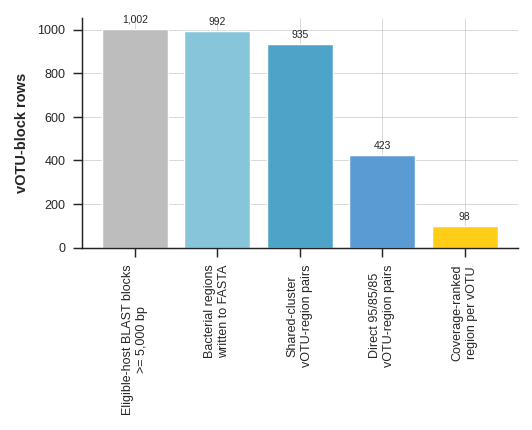

Saved selected vOTU blocks: /home/lmf/PhylloVir/VIRAL_WORLD/VIRAL_FRACTION/FIGURES_AND_TABLES/SUPPLEMENTARY/09_vOTU_block_test_set/09_vOTU_blocks_clustered_coverage_ranked.csv


In [11]:
# Summarize and plot the selected vOTU blocks
selection_summary = pd.DataFrame([
    {
        'step': f'Eligible-host BLAST blocks >= {MIN_BLOCK_LENGTH_BP:,} bp',
        'n_rows': len(blast_blocks),
        'n_vOTUs': blast_blocks['qseqid'].nunique(),
    },
    {
        'step': 'Bacterial regions written to FASTA',
        'n_rows': len(regions_to_extract),
        # Regions are deduplicated for FASTA extraction, but they still originate from
        # these same vOTUs; one region can be shared by more than one vOTU.
        'n_vOTUs': blast_blocks['qseqid'].nunique(),
    },
    {
        'step': 'vOTU-region pairs in shared clusters',
        'n_rows': len(shared_cluster_candidates),
        'n_vOTUs': shared_cluster_candidates['qseqid'].nunique(),
    },
    {
        'step': 'Direct >=95% identity and >=85% reciprocal coverage',
        'n_rows': len(clustered_candidates),
        'n_vOTUs': clustered_candidates['qseqid'].nunique(),
    },
    {
        'step': 'Coverage-ranked region per vOTU',
        'n_rows': len(selected_blocks),
        'n_vOTUs': selected_blocks['qseqid'].nunique(),
    },
])
selection_summary.to_csv(outputs['summary'], index=False)

plot_labels = [
    f'Eligible-host BLAST blocks\n>= {MIN_BLOCK_LENGTH_BP:,} bp',
    'Bacterial regions\nwritten to FASTA',
    'Shared-cluster\nvOTU-region pairs',
    'Direct 95/85/85\nvOTU-region pairs',
    'Coverage-ranked\nregion per vOTU',
]
if MAKE_PLOTS:
    x_positions = np.arange(len(selection_summary))
    fig, axis = plt.subplots(figsize=(3.5, 2.8))
    bars = axis.bar(
        x_positions,
        selection_summary['n_rows'],
        color=['#bdbdbd', '#86c5da', '#4ea3c8', '#5a9bd4', '#ffcc17'],
    )
    for bar, value in zip(bars, selection_summary['n_rows']):
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            value + max(selection_summary['n_rows']) * 0.02,
            f'{int(value):,}',
            ha='center',
            va='bottom',
        )
    axis.set_xticks(x_positions)
    axis.set_xticklabels(plot_labels, rotation=90, ha='center', va='top')
    axis.set_ylabel('vOTU-block rows')
    axis.spines[['top', 'right']].set_visible(False)
    fig.tight_layout()
    fig.savefig(outputs['figure'], format='svg', bbox_inches='tight')
    plt.show()
    plt.close(fig)
else:
    print('Plots skipped: set MAKE_PLOTS = True after final selection checks.')

selection_summary
print(f'Saved selected vOTU blocks: {outputs["selected_blocks"]}')
